# 01 — Data: download, EDA, augmentation preview

Downloads NCT-CRC-HE-100K (train) + CRC-VAL-HE-7K (val) into `PERSIST_DIR/data` (once),
shows the class distribution, and previews the Albumentations pipeline incl. `HEDStainJitter`.

In [1]:
# Locate shared.ipynb regardless of the kernel's working directory, then run it.
from pathlib import Path as _P
_sh = next((p for p in [_P.cwd() / "shared.ipynb",
                        _P("/workspace/shared/ft004/shared.ipynb")] if p.exists()), None)
if _sh is None:
    _hits = list(_P.cwd().rglob("shared.ipynb")) or list(_P("/workspace").rglob("shared.ipynb"))
    _sh = _hits[0] if _hits else None
assert _sh, "shared.ipynb not found - keep it beside the notebooks or in /workspace/shared/ft004"
print("running", _sh)
get_ipython().run_line_magic("run", str(_sh))
import os
from pathlib import Path
PERSIST_DIR = Path(os.environ.get("PERSIST_DIR", "/workspace/shared/ft004"))
set_seed(42)


running /workspace/finetuning-004-pathology/shared.ipynb


shared.ipynb loaded: Phase A + B + helpers ready.


In [2]:
# ~10 GB download on first run; cached thereafter. Resumes are no-ops.
paths = ensure_dataset(PERSIST_DIR)
TRAIN_DIR = paths["NCT-CRC-HE-100K"]
VAL_DIR = paths["CRC-VAL-HE-7K"]
print("train:", TRAIN_DIR)
print("val  :", VAL_DIR)


19:48:44 | INFO | NCT-CRC-HE-100K already present: /workspace/shared/ft004/data/NCT-CRC-HE-100K


19:48:44 | INFO | Downloading -> /workspace/shared/ft004/data/CRC-VAL-HE-7K.zip


    2.0%

    4.0%

    6.0%

...

   96.0%

   98.0%

19:49:33 | INFO | Extracting CRC-VAL-HE-7K.zip ...


19:49:56 | INFO | CRC-VAL-HE-7K ready: /workspace/shared/ft004/data/CRC-VAL-HE-7K/CRC-VAL-HE-7K


train: /workspace/shared/ft004/data/NCT-CRC-HE-100K
val  : /workspace/shared/ft004/data/CRC-VAL-HE-7K/CRC-VAL-HE-7K


19:50:00 | INFO | Dataset NCT-CRC-HE-100K: 100000 imgs / 9 classes


19:50:02 | INFO | Dataset CRC-VAL-HE-7K: 7180 imgs / 9 classes


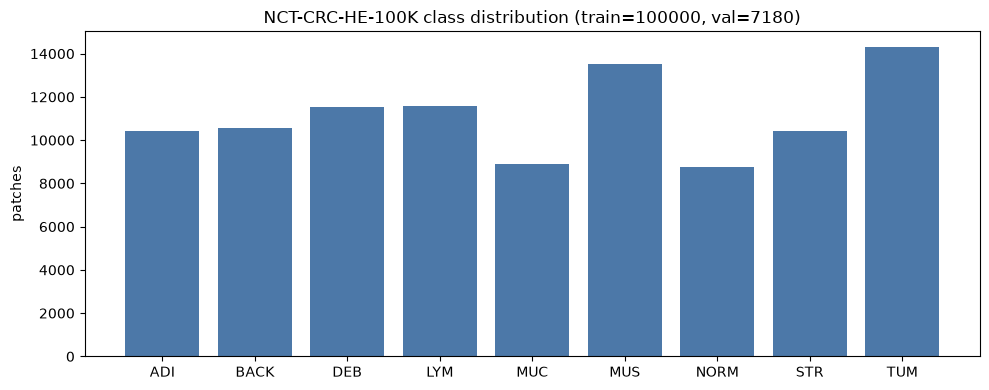

{'ADI': 10407, 'BACK': 10566, 'DEB': 11512, 'LYM': 11557, 'MUC': 8896, 'MUS': 13536, 'NORM': 8763, 'STR': 10446, 'TUM': 14317}


In [3]:
# Class distribution
import matplotlib.pyplot as plt
train_ds = PathologyPatchDataset(TRAIN_DIR, transform=None)
val_ds = PathologyPatchDataset(VAL_DIR, classes=train_ds.classes, transform=None)

from collections import Counter
ctr = Counter(lbl for _, lbl in train_ds.samples)
counts = [ctr[i] for i in range(len(train_ds.classes))]
plt.figure(figsize=(10, 4))
plt.bar(train_ds.classes, counts, color="#4C78A8")
plt.title(f"NCT-CRC-HE-100K class distribution (train={len(train_ds)}, val={len(val_ds)})")
plt.ylabel("patches"); plt.tight_layout(); plt.show()
print({c: ctr[i] for i, c in enumerate(train_ds.classes)})


/tmp/ipykernel_11338/3600200050.py:33: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15),


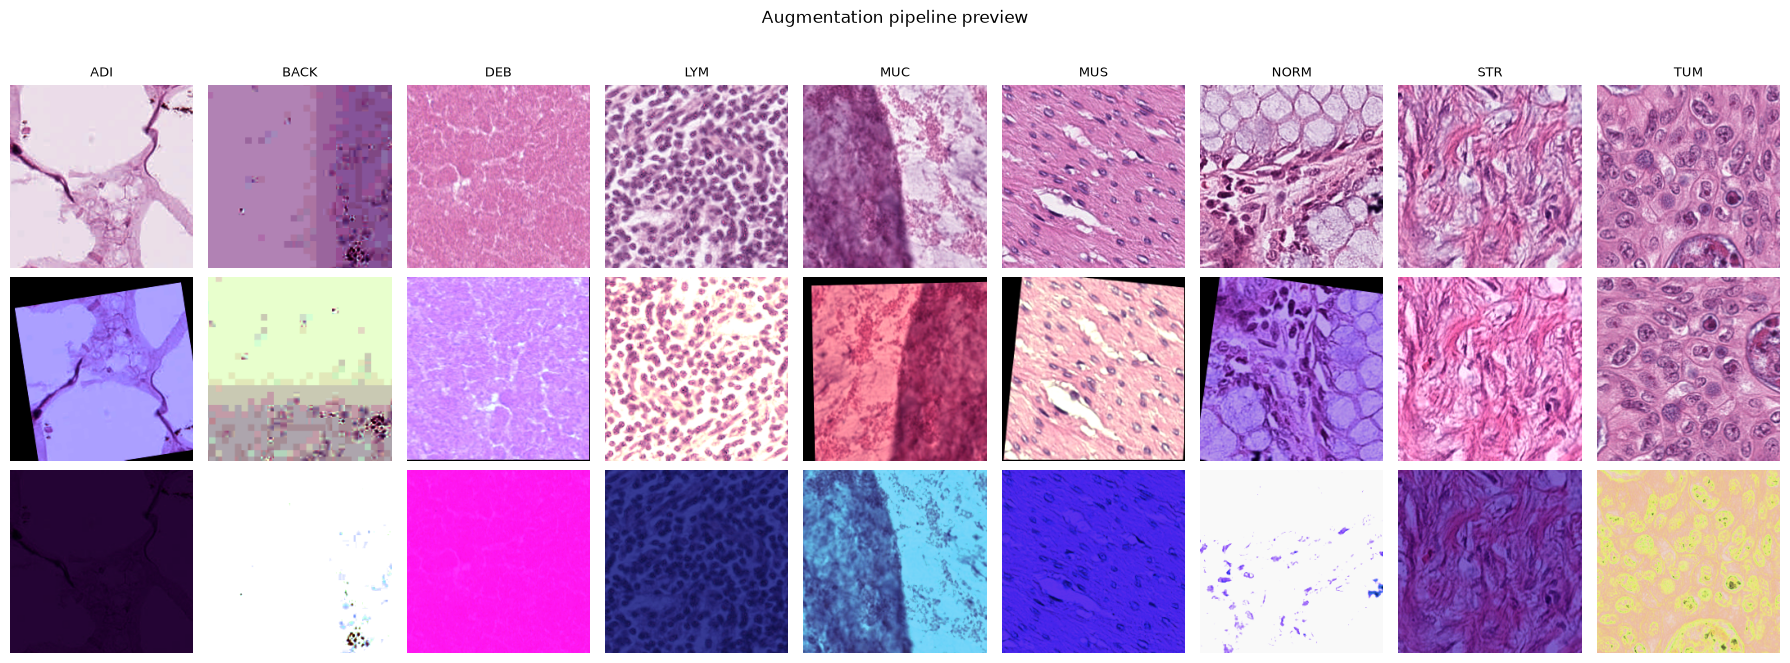

In [4]:
# Augmentation preview: original vs train-aug (with stain) vs strong OOD shift
import numpy as np, matplotlib.pyplot as plt
from PIL import Image

train_aug = build_train_aug(use_stain_aug=True, theta=0.05)
ood_aug = build_ood_aug(theta=0.15)

idxs = [next(i for i, (_, l) in enumerate(train_ds.samples) if l == k)
        for k in range(len(train_ds.classes))]

fig, axes = plt.subplots(3, len(idxs), figsize=(2.0 * len(idxs), 6.5))
for col, i in enumerate(idxs):
    path, lbl = train_ds.samples[i]
    img = np.array(Image.open(path).convert("RGB"))
    aug = denormalize(train_aug(image=img)["image"])
    ood = denormalize(ood_aug(image=img)["image"])
    for row, (im, tag) in enumerate([(img, "orig"), (aug, "train-aug"), (ood, "OOD shift")]):
        axes[row, col].imshow(im); axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(train_ds.classes[lbl], fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(tag, fontsize=10)
plt.suptitle("Augmentation pipeline preview", y=1.02)
plt.tight_layout(); plt.show()
